# Continuous Gravitational Waves in Pulsar Timing Arrays
## Tutorial 2: Searching for the signal

*Adapted from Polina Petrov and Caitlin Witt's work (IPTA GW school 2024 CW tutorial). Simulation code adapted from Matt Miles.*

In Tutorial 1 you simulated a PTA dataset containing a loud CW and learned how the signal model works. Now we get to do the fun part: pretend we don't know what's in the data, and **search** for it.

We'll climb the ladder of CW search techniques:

1. **Frequentist statistics** — the $\mathcal{F}_p$ and $\mathcal{F}_e$ maximum-likelihood statistics: fast, but they only maximize (rather than sample) the parameter space.
2. **Bayesian search with `QuickCW`** — the pipeline used for real NANOGrav CW searches, with an explicit option to search over the pulsar-term parameters.
3. ***(Optional, REQUIRES GPU)*** **`Prometheus`** — a GPU-accelerated, gradient-based (NUTS) sampler built on JAX.

### Package installation

In addition to the Tutorial 1 stack, you need `QuickCW` (which brings in `numba`). Follow the instructions here — and clone/install it in the same environment you're running this notebook in:

https://github.com/nanograv/QuickCW/blob/main/docs/how_to_run_QuickCW.md

We also use two helper files that live next to this notebook: `cw_utils.py` (a modified $\mathcal{F}_e$-statistic class) and `QuickCW_v2.py` (a thin wrapper around `QuickCW` with a simpler white-noise model, appropriate for our simulated data).

In [ ]:
# imports
import json, glob, os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import astropy.units as u
import corner
import healpy as hp

from enterprise import constants as const
from enterprise.signals import parameter, selections, white_signals, gp_signals, signal_base
from enterprise_extensions import load_feathers
from enterprise_extensions.deterministic import cw_delay, CWSignal

# output directory for MCMC chains etc.
outdir = './'

## 0. Load the simulated data

We load the same 12 pulsars as Tutorial 1 and then inject the residuals you simulated there. (If you haven't run Tutorial 1, or want the canonical dataset back, the repository ships with a pre-generated `sim_data/` — just run the cells.)

In [ ]:
# load the pulsars (ignore the dmx/_pdist warnings)
psrs = load_feathers.load_feathers_from_folder('./data_products/')

# load the simulated residuals + injection parameters from Tutorial 1
data = np.load('sim_data/cw_sim_residuals.npz')
with open('sim_data/cw_injection_params.json') as f:
    injection_params = json.load(f)

for psr in psrs:
    psr._pdist = psr.pdist
    # feather-backed arrays are read-only; the search codes need writable ones
    psr.toas = np.array(psr.toas)
    psr.toaerrs = np.array(psr.toaerrs)
    psr.residuals = np.array(data[psr.name])

n_psrs = len(psrs)
print(f'{n_psrs} pulsars loaded')
print('injected CW parameters:')
for k, v in injection_params.items():
    if k.startswith('cw_'):
        print(f'  {k:16s} = {v:.4f}')

FeatherPulsar.read_feather: cannot find dmx in feather file ./data_products/J0030+0451.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ./data_products/J0030+0451.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ./data_products/J0437-4715.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ./data_products/J0437-4715.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ./data_products/J1012+5307.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ./data_products/J1012+5307.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ./data_products/J2145-0750.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ./data_products/J2145-0750.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file ./data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file ./data_products/B1937+21.feather.
FeatherPulsar.read_feather: c

/home/mattm/miniforge3/envs/cw-tutorial/lib/python3.12/site-packages/enterprise/pulsar.py:741: FutureWarning: pyarrow.feather.read_table is deprecated as of 24.0.0. Use pyarrow.ipc.open_file() / RecordBatchFileReader instead. Feather V2 is the Arrow IPC file format.
  f = feather.read_table(filename)


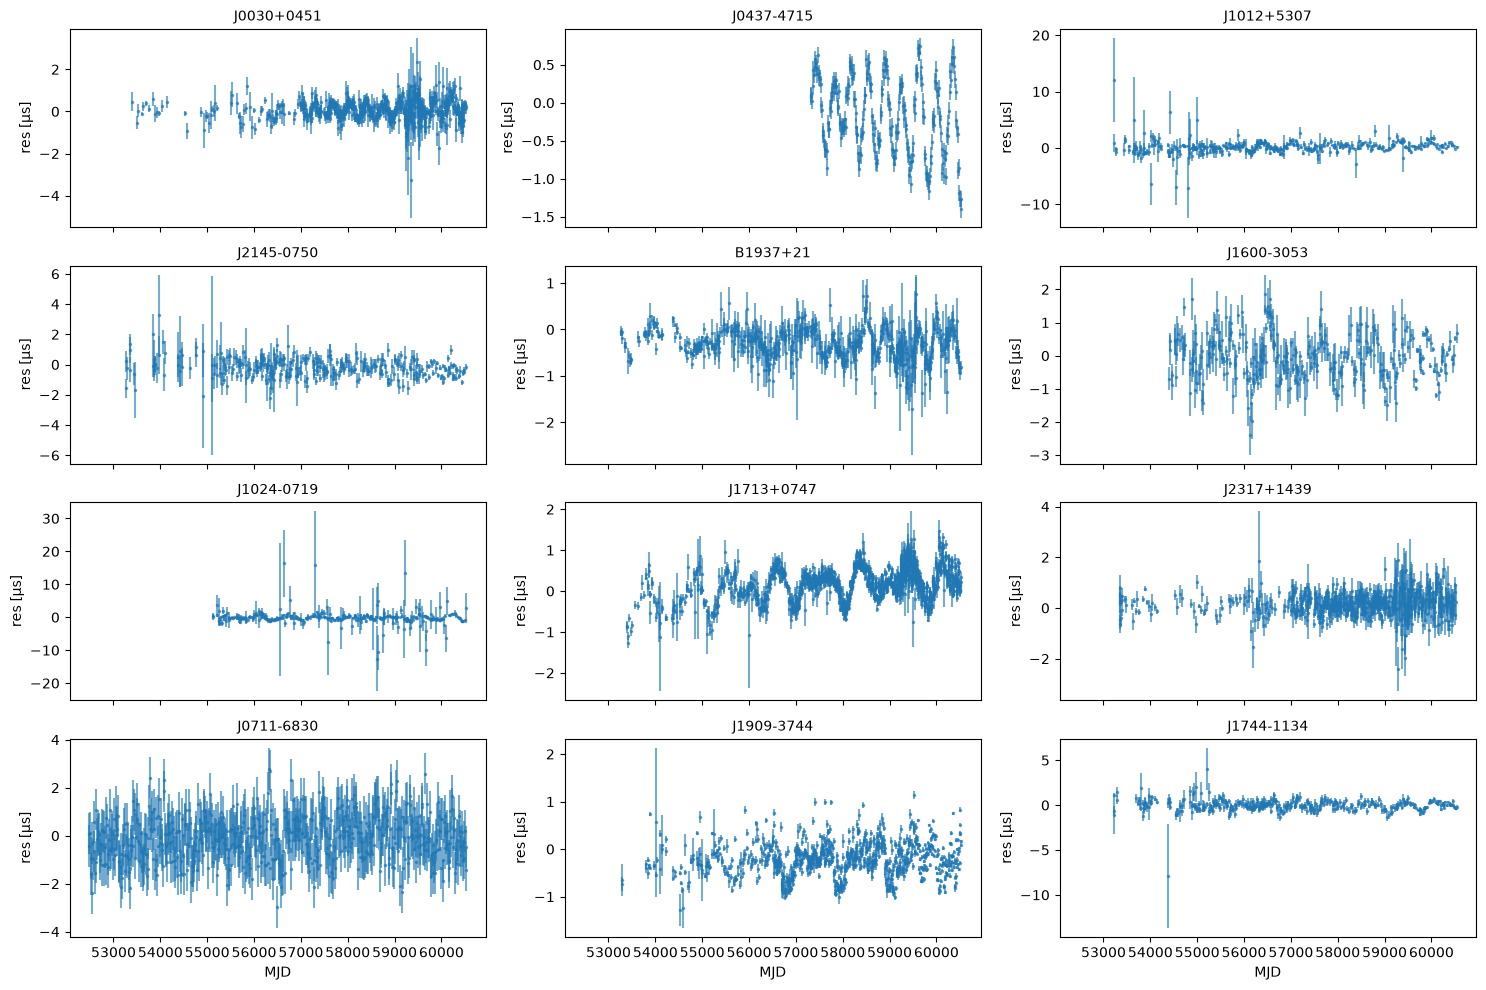

In [ ]:
# what are we searching for? (residuals again, for reference)
fig, axes = plt.subplots(4, 3, figsize=(15, 10), sharex=True)
for ax, psr in zip(axes.ravel(), psrs):
    mjd = (psr.toas*u.s).to(u.day).value
    ax.errorbar(mjd, psr.residuals/1e-6, psr.toaerrs/1e-6, fmt='.', ms=3, alpha=0.6)
    ax.set_title(psr.name, fontsize=10)
    ax.set_ylabel('res [µs]')
for ax in axes[-1]:
    ax.set_xlabel('MJD')
fig.tight_layout()
plt.show()

## 1. Frequentist analyses

There are two frequentist statistics we can use for CW searches — the $\mathcal{F}_e$ statistic and the $\mathcal{F}_p$ statistic — both maximum-likelihood estimators.

**The $\mathcal{F}_e$ statistic** is a maximum-likelihood estimator of the **sky location** $(\theta, \phi)$ and **GW frequency** $f_{\rm gw}$ of an individually-resolvable SMBHB. Its signal model includes **only the Earth term**.

**The $\mathcal{F}_p$ statistic** is a maximum-likelihood estimator of the **GW frequency** of the source. It *does* account for the pulsar term, assuming the source evolves slowly enough that the Earth- and pulsar-term frequencies are indistinguishable.

For the math, see https://arxiv.org/abs/1112.1075 and https://arxiv.org/abs/1204.4218.

### Set up the signal model

First we need our `enterprise` signal model. This is the *search* model — compare it to the *injection* model from Tutorial 1: same white noise and timing model, but now the CW parameters are `Parameter` objects with **priors** instead of fixed injected values. This is exactly how `enterprise` represents a signal model: a sum of `Signal` objects, each contributing either a deterministic delay or a Gaussian-process covariance, with named parameters attached.

In [ ]:
# Reference time for the CW model. phase0 (and, for an evolving binary, the
# frequency) are defined AT this epoch, so every code we use has to adopt the
# same tref or the recovered values won't be comparable to the injected ones.
# QuickCW hard-codes MJD 53000, so that is what we use everywhere.
tref = 53000.0 * 86400.0

# white noise fixed at the injected level
efac = parameter.Constant(1)
selection = selections.Selection(selections.no_selection)
ef = white_signals.MeasurementNoise(efac=efac, selection=selection)

# timing model
tm = gp_signals.TimingModel()

# CW signal with priors on each parameter
# assumes NO evolution across the observing span of the dataset
# assumes YES evolution between the pulsar terms and the Earth term
cw_wf = cw_delay(cos_gwtheta=parameter.Uniform(-1, 1)('cos_gwtheta'),
                 gwphi=parameter.Uniform(0, 2*np.pi)('gwphi'),
                 log10_h=parameter.Uniform(-18, -11)('log10_h'),
                 log10_mc=parameter.Uniform(7, 10)('log10_mc'),
                 log10_fgw=parameter.Uniform(-9, -7)('log10_fgw'),
                 cos_inc=parameter.Uniform(-1, 1)('cos_inc'),
                 psi=parameter.Uniform(0, np.pi)('psi'),
                 phase0=parameter.Uniform(0, 2*np.pi)('phase0'),
                 p_dist=parameter.Normal(0, 1),
                 p_phase=parameter.Uniform(0, 2*np.pi),
                 phase_approx=True,  # monochromatic within the data span
                 psrTerm=True,
                 evolve=False,
                 tref=tref)
cw = CWSignal(cw_wf, psrTerm=True)

s = ef + tm + cw

# create the PTA object and have a look at the parameters + priors
pta = signal_base.PTA([s(psr) for psr in psrs])
pta.params

[B1937+21_cw_p_dist:Normal(mu=0, sigma=1),
 B1937+21_cw_p_phase:Uniform(pmin=0, pmax=6.283185307179586),
 J0030+0451_cw_p_dist:Normal(mu=0, sigma=1),
 J0030+0451_cw_p_phase:Uniform(pmin=0, pmax=6.283185307179586),
 J0437-4715_cw_p_dist:Normal(mu=0, sigma=1),
 J0437-4715_cw_p_phase:Uniform(pmin=0, pmax=6.283185307179586),
 J0711-6830_cw_p_dist:Normal(mu=0, sigma=1),
 J0711-6830_cw_p_phase:Uniform(pmin=0, pmax=6.283185307179586),
 J1012+5307_cw_p_dist:Normal(mu=0, sigma=1),
 J1012+5307_cw_p_phase:Uniform(pmin=0, pmax=6.283185307179586),
 J1024-0719_cw_p_dist:Normal(mu=0, sigma=1),
 J1024-0719_cw_p_phase:Uniform(pmin=0, pmax=6.283185307179586),
 J1600-3053_cw_p_dist:Normal(mu=0, sigma=1),
 J1600-3053_cw_p_phase:Uniform(pmin=0, pmax=6.283185307179586),
 J1713+0747_cw_p_dist:Normal(mu=0, sigma=1),
 J1713+0747_cw_p_phase:Uniform(pmin=0, pmax=6.283185307179586),
 J1744-1134_cw_p_dist:Normal(mu=0, sigma=1),
 J1744-1134_cw_p_phase:Uniform(pmin=0, pmax=6.283185307179586),
 J1909-3744_cw_p_dist:N

### The $\mathcal{F}_p$ search

The $\mathcal{F}_p$ statistic involves just one parameter — the GW frequency — so we can do a quick grid search from 1 to 100 nHz and see where it peaks. The peak should be near the injected frequency.

In [ ]:
from enterprise_extensions.frequentist.F_statistic import FpStat

# main inputs: the dataset (pulsar objects) and the PTA object
Fp_obj = FpStat(psrs, noisedict={}, psrTerm=True,
                bayesephem=False, pta=pta, tnequad=False)

In [ ]:
# grid of frequencies (log-spaced, as always for CW searches)
N_freqs = 200
freqs = np.logspace(-9, -7, N_freqs)

# compute the Fp statistic at each frequency
Fps = np.array([Fp_obj.compute_Fp(freq) for freq in freqs])

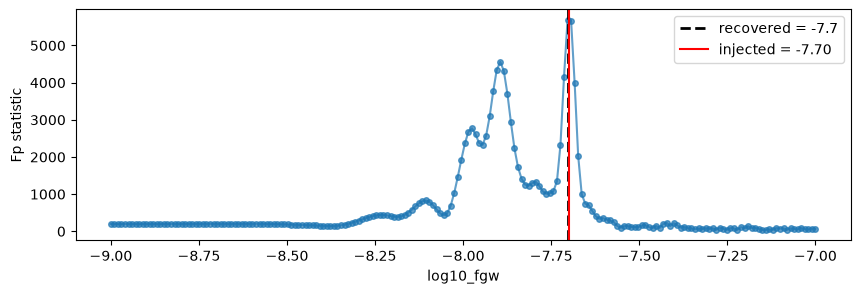

In [ ]:
# plot the Fp statistic vs frequency
plt.figure(figsize=(10, 3))
plt.plot(np.log10(freqs), Fps, marker='o', markersize=4, ls='-', alpha=0.7)

# find the frequency at the maximum Fp value and plot it
w_max = np.argmax(Fps)
fgw_rec = freqs[w_max]
plt.axvline(np.log10(fgw_rec), color='k', ls='dashed', lw=2,
            label=f'recovered = {round(np.log10(fgw_rec), 2)}')

# plot the injected frequency
plt.axvline(injection_params['cw_log10_fgw'], color='r',
            label=f"injected = {injection_params['cw_log10_fgw']:.2f}")

plt.xlabel('log10_fgw'); plt.ylabel('Fp statistic')
plt.legend(loc='upper right')
plt.show()

**What is the maximum-likelihood frequency you recovered? Did the grid search find the injected value?**

### The $\mathcal{F}_e$ search

Now three parameters: GW frequency and sky location. We'll fix the frequency to the $\mathcal{F}_p$ recovery and map the $\mathcal{F}_e$ statistic over the **whole sky**, using the modified `FeStat` class in `cw_utils.py`.

A trick makes this cheap: the expensive TOA-dependent inner products in $\mathcal{F}_e$ don't depend on the sky location — only the antenna patterns do. So `compute_Fe` accepts an *array* of sky positions and only pays the expensive part once. We evaluate it on a HEALPix grid and plot the resulting maximum-likelihood skymap.

In [ ]:
from cw_utils import FeStat

Feobj = FeStat(psrs, params={}, pta=pta)

In [ ]:
# evaluate Fe on a HEALPix grid over the whole sky
nside = 16
npix = hp.nside2npix(nside)
theta_grid, phi_grid = hp.pix2ang(nside, np.arange(npix))

fe_map = Feobj.compute_Fe(f0=fgw_rec, gw_skyloc=np.vstack([theta_grid, phi_grid]),
                          tref=tref)
print('max log10(Fe) =', np.log10(fe_map.max()))

max log10(Fe) = 3.742536506320477


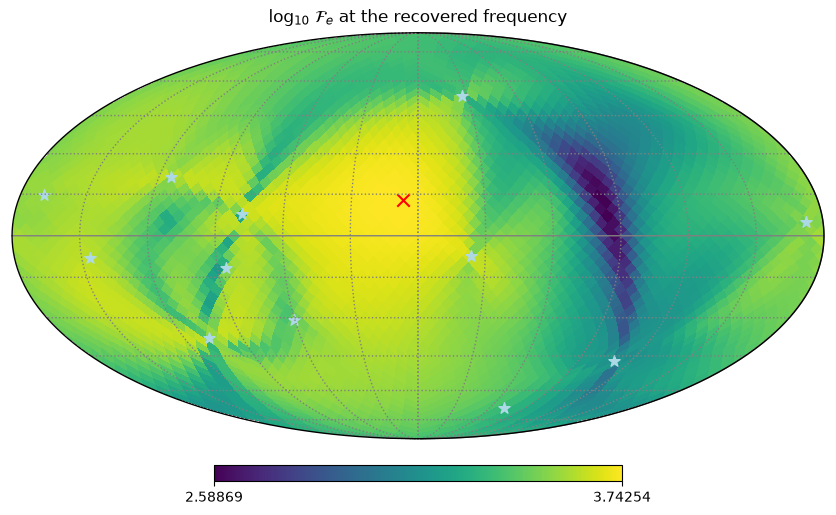

Fe max at  theta=1.361, phi=3.338
injected:  theta=1.349, phi=3.259


In [ ]:
# where does the Fe statistic think the source is?
hp.mollview(np.log10(fe_map), rot=180, title=r'$\log_{10}\,\mathcal{F}_e$ at the recovered frequency')
for psr in psrs:
    hp.visufunc.projscatter(psr.theta, psr.phi, marker='*', s=70, color='lightblue')
# injected sky location
hp.visufunc.projscatter(np.arccos(injection_params['cw_cos_gwtheta']),
                        injection_params['cw_gwphi'],
                        marker='x', s=80, color='r')
hp.graticule(15, 30, color='gray')
plt.show()

# best-fit sky position vs injection
best = np.argmax(fe_map)
print(f'Fe max at  theta={theta_grid[best]:.3f}, phi={phi_grid[best]:.3f}')
print(f'injected:  theta={np.arccos(injection_params["cw_cos_gwtheta"]):.3f}, '
      f'phi={injection_params["cw_gwphi"]:.3f}')

**Did the $\mathcal{F}_e$ map peak near the red X?** The hotspot is usually in the right region but broad and lumpy: the $\mathcal{F}_e$ statistic is Earth-term-only, and it *maximizes* (rather than marginalizes) over the other parameters, so it gives no real uncertainty quantification. Time to bring out the full Bayesian machinery...

## 2. Bayesian analysis with `QuickCW`

Now we search using the **full likelihood**. [`QuickCW`](https://github.com/nanograv/QuickCW) is an MCMC sampler built on top of `enterprise`: `enterprise` supplies the priors and signal model, while `QuickCW` swaps in a custom fast likelihood with a Metropolis-within-Gibbs sampler and Multiple-Try MCMC. The trick that makes it "quick": most proposed jumps only change *projection* parameters (amplitude, phases, polarization...) for which the expensive inner products can be reused, so millions of iterations are cheap.

In a full CW search we sample the 8 global CW parameters $\{\cos\theta, \phi, f_{\rm gw}, \mathcal{M}, h_0, \iota, \psi, \Phi_0\}$ **plus $2N_{\rm psr}$ pulsar-term parameters**: the pulsar distance $L_i$ and pulsar-term phase $\Phi_i$ for every pulsar in the array.

### Searching the pulsar terms

The pulsar term is *always* part of `QuickCW`'s signal model — as you saw in Tutorial 1, the data physically contain it, and it carries the chirp-mass information. What you *can* choose is whether the sampler actively **searches over the pulsar distances** (with a Gaussian prior from each pulsar's measured distance), or keeps them pinned at their starting values. The flag below controls this via the weight of distance jump proposals.

**Note:** we use `QuickCW_v2.py` (in this folder) instead of `QuickCW.py` — it's the same engine with a much simpler white-noise model, matching our simulated data.

In [ ]:
import QuickCW_v2   # thin wrapper around QuickCW, simple white-noise model
from QuickCW.QuickMCMCUtils import ChainParams

# ------------------------------------------------------------------
# EXPLICIT OPTION: search over the pulsar-term distances?
SEARCH_PULSAR_TERMS = True
# ------------------------------------------------------------------
dist_jump_weight = 0.2 if SEARCH_PULSAR_TERMS else 0.0

### MCMC setup

These are the `QuickCW` sampling parameters, dialed down so this runs in roughly 10 minutes on a laptop. A real analysis would use 100 million – 1 billion iterations; our signal is loud and the data are small, so a few million goes a long way. (Watch the status printouts: once the best log-likelihood stops improving between blocks, the chain has probably found the source.)

Two of these settings deserve attention, because they are what makes or breaks the run on a dataset like ours:

- **`n_int_block`** — iterations per block. Each block contains exactly *one* "shape" update (sky location, frequency, chirp mass — the parameters that require an expensive recomputation of the inner products) and `n_int_block - 1` cheap "projection" updates (amplitude, phases, polarization). So the number of shape proposals in the whole run is `Niter / n_int_block`, *not* `Niter`. Set this too high and the sky/frequency parameters simply never move.
- **`fisher_eig_downsample`** — how much less often the expensive Fisher *eigendirection* updates are done. The Fisher matrix sets the size and orientation of the proposed jumps; if it is never recomputed, the sampler keeps proposing jumps scaled for wherever it started, which for a sharply-peaked likelihood means essentially zero acceptance.

Our CW is loud and we have 12 pulsars, so the shape likelihood is very sharp — exactly the regime where stale jump proposals get rejected every time. Keeping these two numbers small is what lets the chain actually find the source.

In [ ]:
# number of iterations (increase to 1e8 - 1e9 for a real analysis)
Niter = 8_000_000

n_int_block = 1_000      # iterations per block (ONE shape update + projection updates)
save_every_n = 100_000   # iterations between saving intermediate results
N_blocks = np.int64(Niter//n_int_block)
fisher_eig_downsample = 10   # keep small: sharp likelihood needs fresh jump proposals

n_status_update = 10
n_block_status_update = np.int64(N_blocks//n_status_update)

assert N_blocks % n_status_update == 0
assert Niter % save_every_n == 0
assert Niter % n_int_block == 0

# parallel tempering
T_max = 10.
n_chain = 6

savedir = outdir + 'qcw_samples/'
os.makedirs(savedir, exist_ok=True)

One more trick from real pipelines: we already ran the (cheap) $\mathcal{F}_p$ statistic and found the source frequency. Rather than making `QuickCW` re-search the entire 1–100 nHz band — the hardest part of the problem, since the likelihood is razor-thin in frequency — we hand it a **frequency prior centred on the $\mathcal{F}_p$ recovery**. This frequentist-first, Bayesian-follow-up ladder is exactly how real CW candidates are chased down. (To attempt a fully blind search instead, set `freq_bounds=np.array([1e-9, 1e-7])` and give it a lot more iterations.)

In [ ]:
# object containing the common parameters of the MCMC chain
chain_params = ChainParams(T_max, n_chain, n_block_status_update,
                           # frequency prior informed by the Fp search above!
                           freq_bounds=np.array([fgw_rec/2, fgw_rec*2]),
                           n_int_block=n_int_block,
                           save_every_n=save_every_n,
                           fisher_eig_downsample=fisher_eig_downsample,
                           rn_emp_dist_file=None,
                           savefile=savedir+'samples.h5',
                           thin=100,
                           prior_draw_prob=0.2, de_prob=0.6, fisher_prob=0.3,
                           # jump-type weights -- note dist_jump_weight!
                           dist_jump_weight=dist_jump_weight,
                           rn_jump_weight=0.3, gwb_jump_weight=0.1,
                           common_jump_weight=0.2, all_jump_weight=0.2,
                           # our data contain no red noise or GWB: fix them at ~zero
                           fix_rn=True, zero_rn=True, fix_gwb=True, zero_gwb=True)

# build the enterprise PTA and the MCMC object
# (the first call takes a few minutes: numba is JIT-compiling the fast likelihood)
np.random.seed(20260727)   # for (approximate) reproducibility of the chain
pta_qcw, mcc = QuickCW_v2.QuickCW(chain_params, psrs, noise_json=None,
                                  include_ecorr=False, amplitude_prior='detection',
                                  psr_distance_file=None, backend_selection=False)

Using 6 temperature chains with a geometric spacing of 1.585.
Temperature ladder is:
 [ 1.          1.58489319  2.51188643  3.98107171  6.30957344 10.        ]
Overwrite rn_jump_weight to 0, due to fix_rn=True.
Overwrite gwb_jump_weight to 0, due to fix_gwb=True.
Overwrite all_jump_weight to 0, due to either fix_rn or fix_gwb being True.
Began Main Loop
Begin Loading Pulsar Timing Array from Enterprise at    0.005s
Finished Loading Pulsar Timing Array from Enterprise at    0.005s
List of parameters in the model with their priors:
[0_cos_gwtheta:Uniform(pmin=-1, pmax=1), 0_cos_inc:Uniform(pmin=-1, pmax=1), 0_gwphi:Uniform(pmin=0.0, pmax=6.283185307179586), 0_log10_fgw:Uniform(pmin=-8.00454758360368, pmax=-7.402487592275717), 0_log10_h:Uniform(pmin=-18, pmax=-11), 0_log10_mc:Uniform(pmin=7, pmax=10), 0_phase0:Uniform(pmin=0, pmax=6.283185307179586), 0_psi:Uniform(pmin=0, pmax=3.141592653589793), B1937+21_cw0_p_dist:Normal(mu=0, sigma=1), B1937+21_cw0_p_phase:Uniform(pmin=0, pmax=6.283185

In [ ]:
# run the MCMC!
mcc.advance_N_blocks(N_blocks)

Entering Loop Body at    0.765s
Progress: 0.00% at t=    0.006s forecast loop time      nans
Acceptance fractions for various jumps
Jump Name      chain   0  chain   1  chain   2  chain   3  chain   4  chain   5 
Temperature    1.000e+00  1.585e+00  2.512e+00  3.981e+00  6.310e+00  1.000e+01 
Dist Prior     No Trials  No Trials  No Trials  No Trials  No Trials  No Trials 
Dist DE        No Trials  No Trials  No Trials  No Trials  No Trials  No Trials 
Dist Fisher    No Trials  No Trials  No Trials  No Trials  No Trials  No Trials 
RN DE          No Trials  No Trials  No Trials  No Trials  No Trials  No Trials 
RN Fisher      No Trials  No Trials  No Trials  No Trials  No Trials  No Trials 
GWB DE         No Trials  No Trials  No Trials  No Trials  No Trials  No Trials 
GWB Fisher     No Trials  No Trials  No Trials  No Trials  No Trials  No Trials 
Common Prior   No Trials  No Trials  No Trials  No Trials  No Trials  No Trials 
Common DE      No Trials  No Trials  No Trials  No Trials 

### Visualize results

The chain is saved as HDF5. We read the cold chain and the parameter names, then check the recovery of the 8 CW parameters against the injected values.

In [ ]:
import h5py

with h5py.File(savedir+'samples.h5', 'r') as f:
    print('File keys:', list(f.keys()))
    samples = f['samples_cold'][0, :, :]
    par_names = [x.decode('UTF-8') for x in list(f['par_names'])]
print('Number of samples:', samples.shape)
print(par_names)

File keys: ['T-ladder', 'acc_fraction', 'fisher_diag', 'log_likelihood', 'par_names', 'samples_cold', 'samples_freq']
Number of samples: (80000, 58)
['0_cos_gwtheta', '0_cos_inc', '0_gwphi', '0_log10_fgw', '0_log10_h', '0_log10_mc', '0_phase0', '0_psi', 'B1937+21_cw0_p_dist', 'B1937+21_cw0_p_phase', 'B1937+21_red_noise_gamma', 'B1937+21_red_noise_log10_A', 'J0030+0451_cw0_p_dist', 'J0030+0451_cw0_p_phase', 'J0030+0451_red_noise_gamma', 'J0030+0451_red_noise_log10_A', 'J0437-4715_cw0_p_dist', 'J0437-4715_cw0_p_phase', 'J0437-4715_red_noise_gamma', 'J0437-4715_red_noise_log10_A', 'J0711-6830_cw0_p_dist', 'J0711-6830_cw0_p_phase', 'J0711-6830_red_noise_gamma', 'J0711-6830_red_noise_log10_A', 'J1012+5307_cw0_p_dist', 'J1012+5307_cw0_p_phase', 'J1012+5307_red_noise_gamma', 'J1012+5307_red_noise_log10_A', 'J1024-0719_cw0_p_dist', 'J1024-0719_cw0_p_phase', 'J1024-0719_red_noise_gamma', 'J1024-0719_red_noise_log10_A', 'J1600-3053_cw0_p_dist', 'J1600-3053_cw0_p_phase', 'J1600-3053_red_noise_gam

In [ ]:
# injected values, mapped to QuickCW's parameter names
injected = {'0_cos_gwtheta': injection_params['cw_cos_gwtheta'],
            '0_cos_inc':     injection_params['cw_cos_inc'],
            '0_gwphi':       injection_params['cw_gwphi'],
            '0_log10_fgw':   injection_params['cw_log10_fgw'],
            '0_log10_h':     injection_params['cw_log10_h'],
            '0_log10_mc':    injection_params['cw_log10_mc'],
            '0_phase0':      injection_params['cw_phase0'],
            '0_psi':         injection_params['cw_psi']}
cw_names = list(injected.keys())
cw_idx = [par_names.index(p) for p in cw_names]

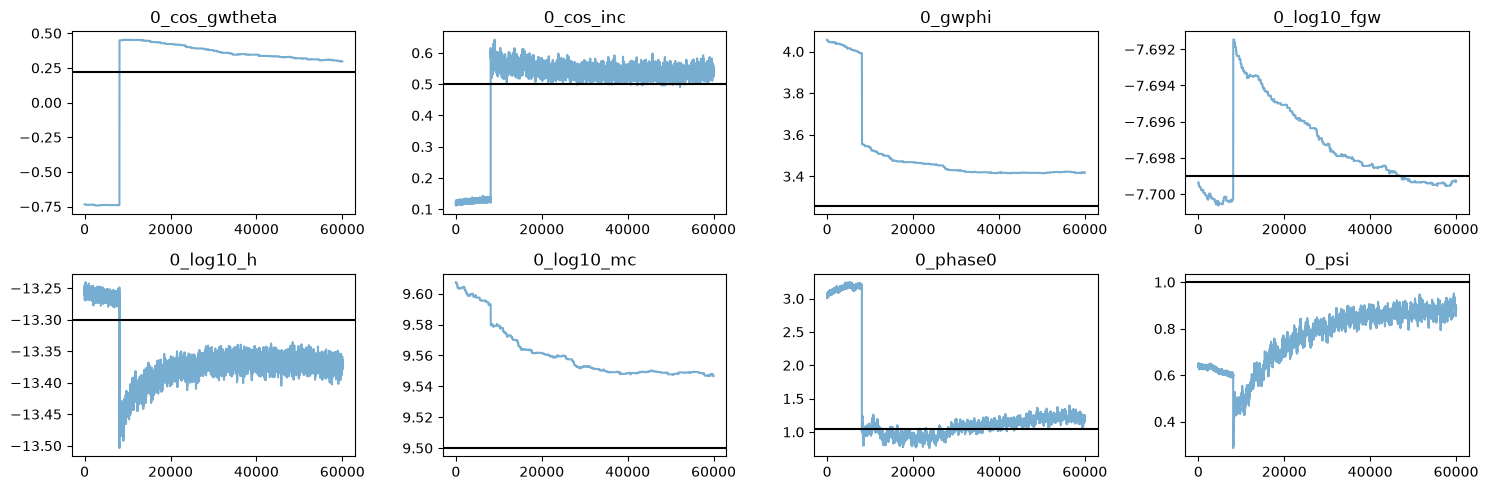

In [ ]:
# burn-in: a quarter of the chain
burn = int(len(samples)/4)

# trace plots of the 8 CW parameters
plt.figure(figsize=(15, 5))
for j, p in enumerate(cw_names):
    plt.subplot(2, 4, j+1)
    plt.plot(samples[burn:, cw_idx[j]], alpha=0.6, color='C0')
    plt.title(p)
    plt.axhline(injected[p], color='k')
plt.tight_layout()
plt.show()

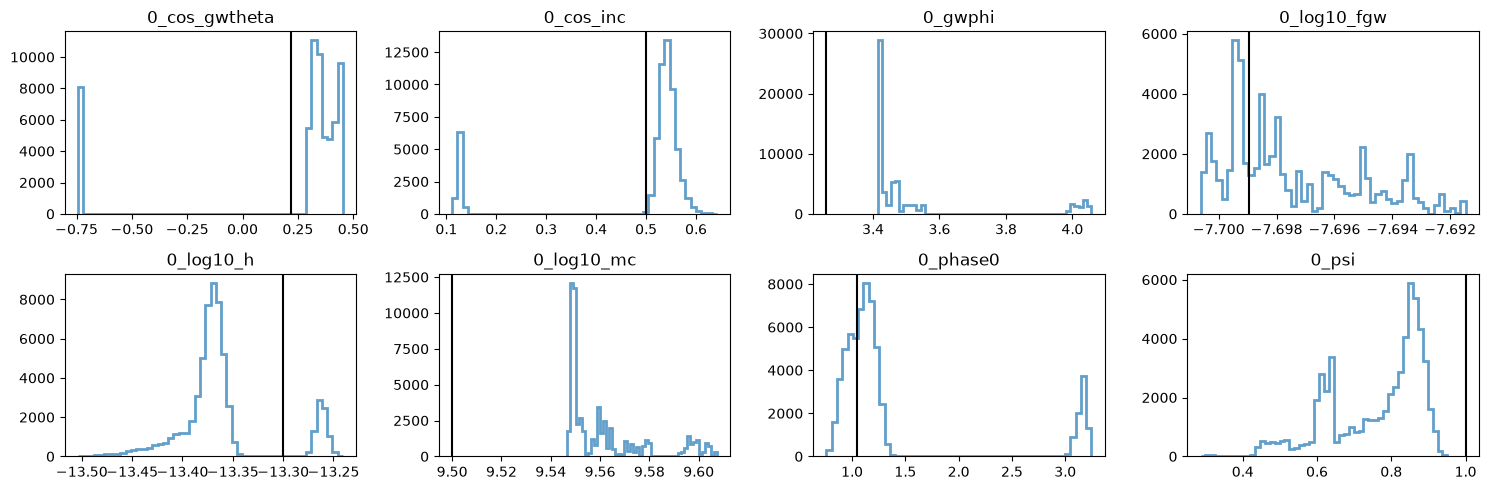

In [ ]:
# histograms of the CW parameter posteriors
plt.figure(figsize=(15, 5))
for j, p in enumerate(cw_names):
    plt.subplot(2, 4, j+1)
    plt.hist(samples[burn:, cw_idx[j]], bins=50, histtype='step', lw=2,
             alpha=0.7, color='C0')
    plt.title(p)
    plt.axvline(injected[p], color='k')
plt.tight_layout()
plt.show()

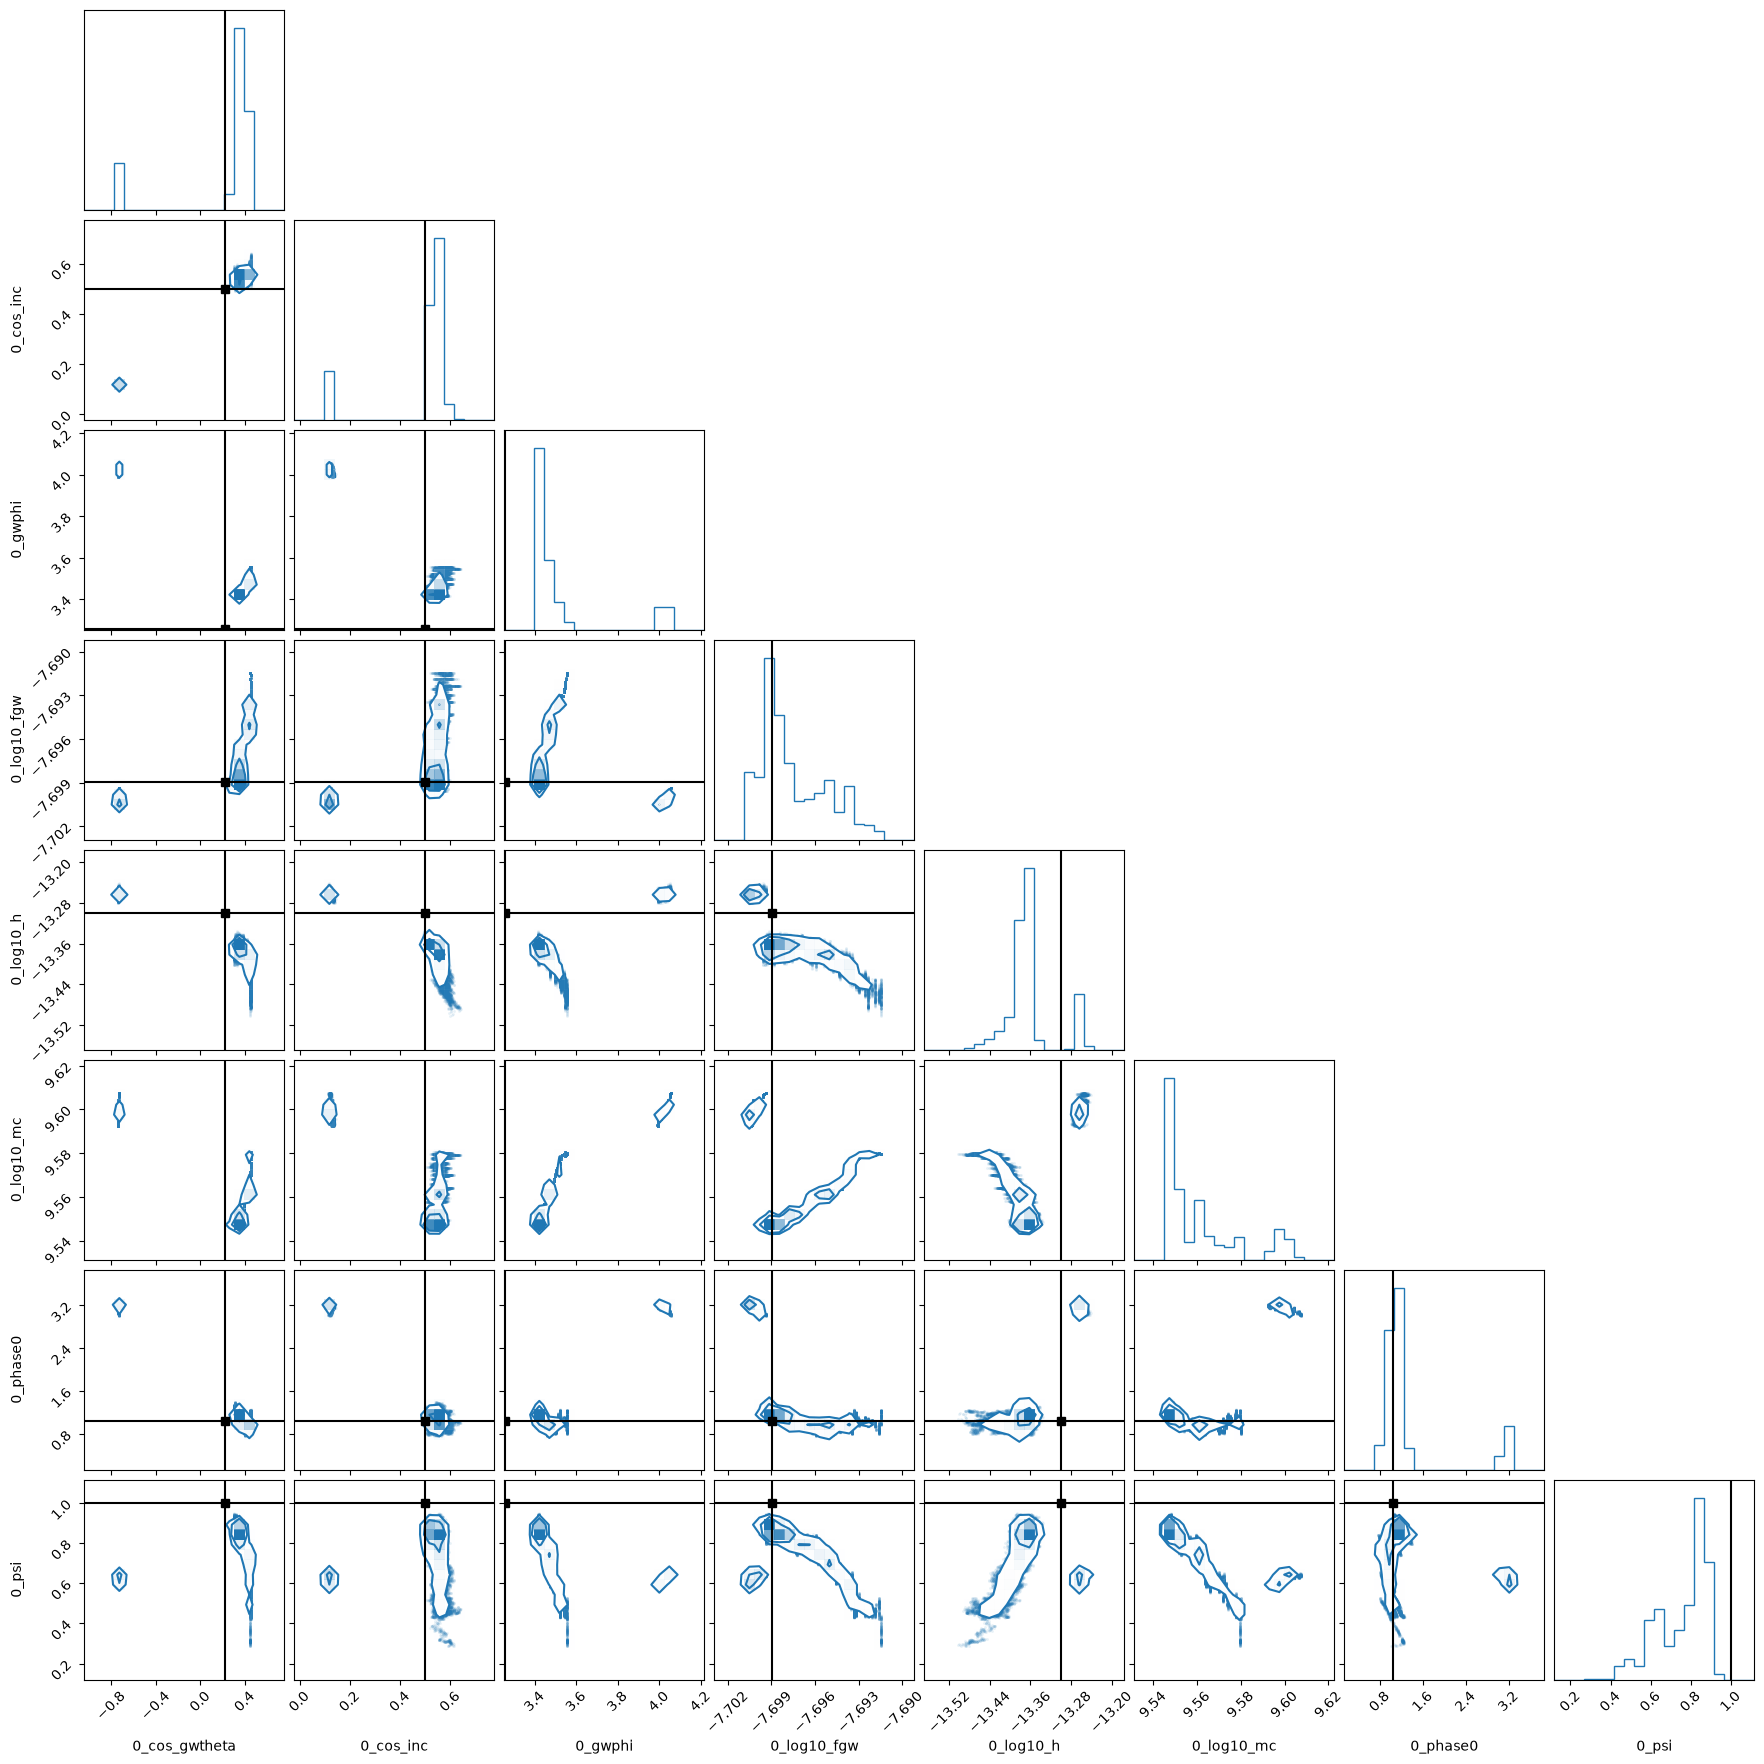

In [ ]:
# corner plot
# (a loud signal makes some posteriors extremely narrow -- give corner
# explicit ranges so the truth lines stay visible)
rng = []
for j in cw_idx:
    lo, hi = samples[burn:, j].min(), samples[burn:, j].max()
    pad = max(0.25*(hi - lo), 1e-3)
    rng.append((lo - pad, hi + pad))

fig = corner.corner(samples[burn:, cw_idx], levels=[0.68, 0.95], range=rng,
                    truths=[injected[p] for p in cw_names],
                    truth_color='k', labels=cw_names, color='C0')
plt.show()

**Was your `QuickCW` run able to recover the injected parameters?**

Most of them should land close to the black lines. Two are worth looking at carefully before you decide anything is broken:

- **$\psi$ and $\Phi_0$ often come out "wrong" together — and that's correct.** The waveform is invariant under $\psi \to \psi + \pi/2$ together with $\Phi_0 \to \Phi_0 + \pi$: rotating the polarization basis by 90° and flipping the phase gives you back exactly the same residuals. So if your run recovers $\psi$ about 1.57 away from the injection *and* $\Phi_0$ about 3.14 away, it has found the right source in the mirror mode. Check whether that's what happened to you.
- **$h_0$, $\mathcal{M}$ and $\iota$ are correlated**, so a small offset in one is usually compensated by the others.

If things look genuinely off, add more iterations — call `mcc.advance_N_blocks(...)` again and the chain continues where it stopped. Also watch the shape parameters (sky location, frequency, chirp mass) in the trace plots: if they sit at a single value forever, the sampler is stuck rather than converged, and the jump-proposal settings (`n_int_block`, `fisher_eig_downsample`) are the things to turn down.

### Comparing waveforms

Posteriors can look imperfect while the reconstructed *waveform* still tracks the signal (and vice versa). Compare the maximum a posteriori (MAP) recovered signal against the injected one.

{'0_cos_gwtheta': np.float32(0.3222108), '0_cos_inc': np.float32(0.54157376), '0_gwphi': np.float32(3.4209619), '0_log10_fgw': np.float32(-7.69944), '0_log10_h': np.float32(-13.369494), '0_log10_mc': np.float32(9.548396), '0_phase0': np.float32(1.131582), '0_psi': np.float32(0.8512411)}


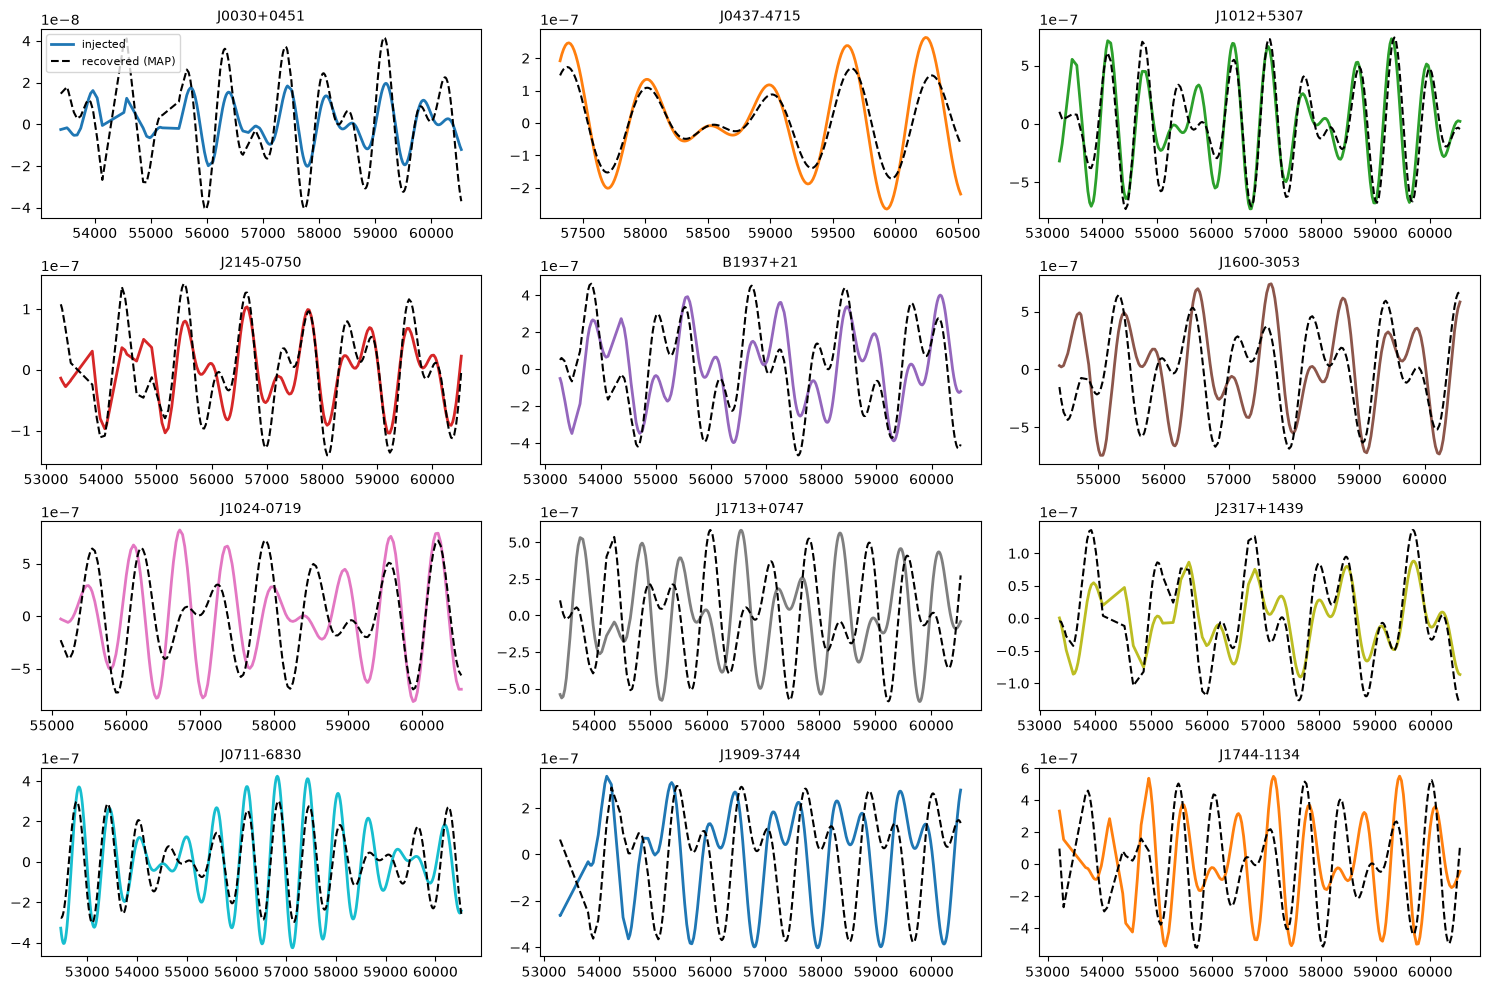

In [ ]:
# make a dictionary of MAP values for the CW parameters
recovered = {}
for p, idx in zip(cw_names, cw_idx):
    hist, bins = np.histogram(samples[burn:, idx], bins=50)
    bin_mid = 0.5*(bins[1:] + bins[:-1])
    recovered[p] = bin_mid[np.argmax(hist)]
print(recovered)

plt.figure(figsize=(15, 10))
for i, psr in enumerate(psrs):
    ax = plt.subplot(4, 3, i+1)
    mjd = (psr.toas*u.s).to(u.day).value

    # injected CW signal
    cw_in = cw_delay(psr.toas.copy(), psr.pos, pdist=psr.pdist,
                     cos_gwtheta=injection_params['cw_cos_gwtheta'],
                     gwphi=injection_params['cw_gwphi'],
                     log10_h=injection_params['cw_log10_h'],
                     log10_fgw=injection_params['cw_log10_fgw'],
                     log10_mc=injection_params['cw_log10_mc'],
                     cos_inc=injection_params['cw_cos_inc'],
                     psi=injection_params['cw_psi'],
                     phase0=injection_params['cw_phase0'],
                     p_dist=0, psrTerm=True, evolve=True, phase_approx=False, tref=tref)

    # MAP recovered CW signal
    cw_out = cw_delay(psr.toas.copy(), psr.pos, pdist=psr.pdist,
                      cos_gwtheta=recovered['0_cos_gwtheta'],
                      gwphi=recovered['0_gwphi'],
                      log10_h=recovered['0_log10_h'],
                      log10_fgw=recovered['0_log10_fgw'],
                      log10_mc=recovered['0_log10_mc'],
                      cos_inc=recovered['0_cos_inc'],
                      psi=recovered['0_psi'],
                      phase0=recovered['0_phase0'],
                      p_dist=0, psrTerm=True, evolve=True, phase_approx=False, tref=tref)

    ax.plot(mjd, cw_in, color=f'C{i%10}', lw=2, label='injected')
    ax.plot(mjd, cw_out, color='k', ls='--', lw=1.5, label='recovered (MAP)')
    ax.set_title(psr.name, fontsize=10)
    if i == 0:
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### The pulsar-term posteriors

Since we sampled the pulsar terms, let's actually *look* at them — most tutorials stop at the 8 global parameters. For each pulsar, `QuickCW` sampled:

- `_cw0_p_dist` — the pulsar distance, as an offset from the measured value in units of its uncertainty (so the injected value is 0), and
- `_cw0_p_phase` — the pulsar-term phase.

Remember the violently multimodal distance likelihood from Tutorial 1? Here's what the sampler made of it.

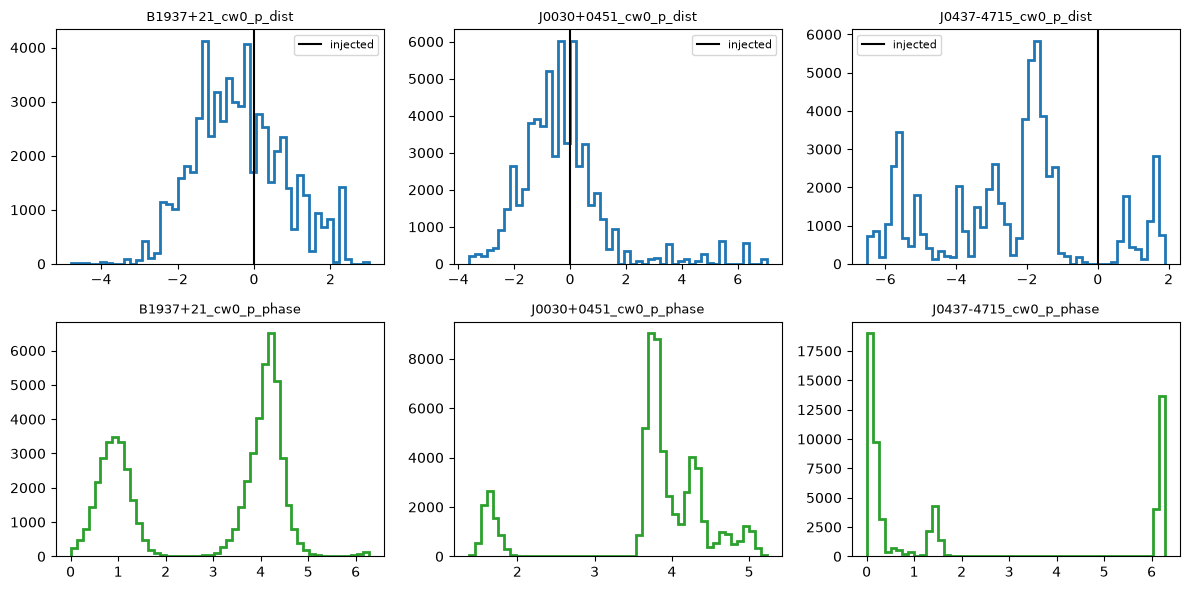

In [ ]:
pdist_names = [p for p in par_names if p.endswith('_cw0_p_dist')]
pphase_names = [p for p in par_names if p.endswith('_cw0_p_phase')]

show = [0, 1, 2]  # first three pulsars; look at the others too!
fig, axes = plt.subplots(2, len(show), figsize=(4*len(show), 6))
for k, i in enumerate(show):
    jd = par_names.index(pdist_names[i])
    jp = par_names.index(pphase_names[i])
    axes[0, k].hist(samples[burn:, jd], bins=50, histtype='step', lw=2, color='C0')
    axes[0, k].axvline(0, color='k', label='injected')
    axes[0, k].set_title(pdist_names[i], fontsize=9)
    axes[0, k].legend(fontsize=8)
    axes[1, k].hist(samples[burn:, jp], bins=50, histtype='step', lw=2, color='C2')
    axes[1, k].set_title(pphase_names[i], fontsize=9)
plt.tight_layout()
plt.show()

**Questions to discuss:**

- Are the distance posteriors single-peaked? Compare pulsars close to the source on the sky with ones far away — who constrains their distance better, and why?
- Rerun the search with `SEARCH_PULSAR_TERMS = False` (you'll want to change `savedir` so you don't overwrite this chain). How do the recovered chirp mass and frequency posteriors change? This connects directly to the "why the pulsar term matters" discussion in Tutorial 1: without exploring the pulsar terms, you lose the handle on the binary's evolution.

### Sky localization

One of the most important products of a CW search is the **sky location** posterior — if we know where the source is, we can go hunting for host galaxies and electromagnetic counterparts. Let's project our samples onto the sky with `healpy`.

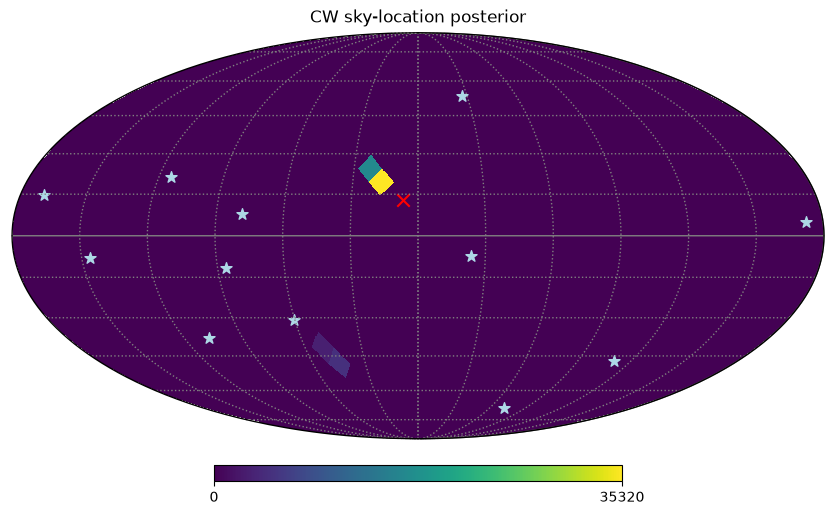

In [ ]:
def post2hpx(theta, phi, nside=8):
    """Convert sky-location samples into a HEALPix map of sample counts."""
    npix = hp.nside2npix(nside)
    indices = hp.ang2pix(nside, theta, phi)
    idx, counts = np.unique(indices, return_counts=True)
    hpx_map = np.zeros(npix, dtype=int)
    hpx_map[idx] = counts
    return hpx_map

costheta_samples = samples[burn:, par_names.index('0_cos_gwtheta')]
phi_samples = samples[burn:, par_names.index('0_gwphi')]

hpx_map = post2hpx(np.arccos(costheta_samples), phi_samples, nside=8)

hp.mollview(hpx_map, rot=180, title='CW sky-location posterior')
for psr in psrs:
    hp.visufunc.projscatter(psr.theta, psr.phi, marker='*', s=70, color='lightblue')
hp.visufunc.projscatter(np.arccos(injection_params['cw_cos_gwtheta']),
                        injection_params['cw_gwphi'],
                        marker='x', s=80, color='r')
hp.graticule(15, 30, color='gray')
plt.show()

The colored pixels are the posterior samples (brighter = more samples), light-blue stars are the pulsars, and the red X is the injected location. **Play with `nside`** (powers of 2) to change the resolution.

Even for our very loud signal, the localization region spans hundreds of square degrees — sifting through all the galaxies in a patch like that is the multimessenger challenge of PTA CW astronomy.

### Extra experiments 🚀

- Go back to Tutorial 1, regenerate the dataset with `include_gwb=True` (and/or red noise), re-save, and rerun this notebook. With `fix_gwb`/`zero_gwb` flipped to `False`, how does the GWB affect the CW recovery?
- Make the CW quieter (`cw_log10_h = -13.5` or `-14`) and see the posteriors broaden and the sky map spread out.
- Targeted search: restrict `cos_gwtheta_bounds`/`gwphi_bounds` in `ChainParams` around the true location — this is how real targeted searches gain sensitivity.

## 3. (Optional) GPU-accelerated search with `Prometheus`

# ⚠️ REQUIRES GPU ⚠️

This section needs an **NVIDIA GPU with CUDA-enabled JAX** — most laptops can't run it, so treat it as a demo to read (or to run later on a cluster / Colab GPU runtime). Everything above this cell runs fine on CPU; nothing below is required for the tutorial.

[`Prometheus`](https://github.com/XGI-MSU/prometheus) takes a completely different approach from `QuickCW`:

- the entire PTA likelihood is written in **JAX**, so it is differentiable end-to-end (exactly like the `discovery` likelihood you met in Tutorial 1 — same idea, tuned for GPUs);
- instead of Metropolis-Hastings-style jumps, it uses **NumPyro's No-U-Turn Sampler (NUTS)**, a gradient-based Hamiltonian Monte Carlo method;
- it samples *everything* jointly — CW parameters, pulsar terms, per-pulsar red noise, the GWB (CURN or full HD correlations!), and even all the Fourier coefficients of the stochastic processes: a ~1000+-dimensional parameter space, which is exactly where gradient-based samplers shine.

For scale: full CW + GWB parameter estimation on the NANOGrav 15-year dataset takes ~15 minutes on an RTX 3090.

Install with:
```bash
pip install git+https://github.com/XGI-MSU/prometheus.git
```

Set the flag below to `True` if you have a GPU.

In [ ]:
RUN_PROMETHEUS = False   # <--- set True only on a machine with an NVIDIA GPU

if RUN_PROMETHEUS:
    import jax
    import jax.random as jr
    import numpyro

    from prometheus import data as prom_data
    from prometheus.spectral_models import IndependentSpectralModel, CommonSpectralModel
    from prometheus import spectra
    from prometheus.deterministic_models import DeterministicModel
    from prometheus import deterministic as prom_deterministic
    from prometheus.pta_model import PTAModel
    from prometheus import utilities as prom_utils
    from prometheus import posterior as prom_posterior

    # this should print something like [CudaDevice(id=0)]
    print(jax.devices())

In [ ]:
if RUN_PROMETHEUS:
    # ---- build the prometheus Data object from our pulsars ----
    # white-noise dictionary at the injected levels
    wn_dict = {}
    for psr in psrs:
        wn_dict[psr.name + '_KAT_MKBF_efac'] = 1.0
        wn_dict[psr.name + '_KAT_MKBF_log10_t2equad'] = -8.0

    # pulsar distances (measured value and uncertainty) for the pulsar terms
    psr_dists_dict = {psr.name: np.array(psr.pdist) for psr in psrs}

    sim_data = prom_data.Data(name='cw_school_sim',
                              psrs=psrs,
                              wn_dict=wn_dict,
                              nfreqs=30,
                              psr_dists_dict=psr_dists_dict)

In [ ]:
if RUN_PROMETHEUS:
    # ---- spectral models ----
    # intrinsic red noise: power law, applied independently to every pulsar
    psr_model = IndependentSpectralModel(name='psr_params',
                                         get_phi_diag_func=spectra.power_law,
                                         parameter_bounds=[[-20., -10.],  # log10_A
                                                           [0., 7.]],     # gamma
                                         data=sim_data)

    # GWB: power law; 'CURN' ignores correlations, or try 'HD'!
    gwb_model = CommonSpectralModel(name='gwb_params',
                                    get_phi_diag_func=spectra.power_law,
                                    parameter_bounds=[[-20., -10.],
                                                      [0., 7.]],
                                    correlation_matrix='CURN',
                                    data=sim_data,
                                    nfreqs=14)

In [ ]:
if RUN_PROMETHEUS:
    # ---- the CW as a deterministic model ----
    # parameter order: log10_mc, log10_fgw, cos_inc, psi, log10_h,
    #                  cos_gwtheta, gwphi, phase0
    cw_param_mins = np.array([7.0, -9.0, -1., 0.,      -18., -1., 0.,        0.])
    cw_param_maxs = np.array([10.0, -7.0, 1., np.pi,   -11.,  1., 2.*np.pi, 2.*np.pi])
    cw_parameter_bounds = np.array([cw_param_mins, cw_param_maxs]).T

    # NANOGrav-style pulsar-distance prior (Arzoumanian et al. 2023, eqs. 20-21)
    psr_dists_lnprior = prom_posterior.build_psr_dists_lnprior(sim_data)

    cw_model = DeterministicModel(name='cw_params',
                                  data=sim_data,
                                  get_delays_func=prom_deterministic.cw_delay_evolve_float32,
                                  parameter_bounds=cw_parameter_bounds,
                                  with_psr_params=True,   # pulsar terms!
                                  additional_ln_factor=psr_dists_lnprior)

    # ---- put it all together ----
    pta_model = PTAModel(psr_model=psr_model,
                         gwb_model=gwb_model,
                         det_model=cw_model)

In [ ]:
if RUN_PROMETHEUS:
    # ---- sample with NUTS ----
    nuts_kernel = numpyro.infer.NUTS(model=pta_model.sampling_model)
    mcmc = numpyro.infer.MCMC(sampler=nuts_kernel,
                              num_warmup=500,
                              num_samples=2000)

    # if the sampler warms up badly (step size < ~1e-5), rerun with a new seed
    seed = 200129
    mcmc.run(jr.PRNGKey(seed))
    prom_samples = mcmc.get_samples()

    prom_utils.save_chain(samples_dict=prom_samples,
                          filepath=savedir+'prometheus_cw.feather',
                          save_coeff_samples=False)

In [ ]:
if RUN_PROMETHEUS:
    # ---- compare the CW posterior against the injection ----
    # 'cw_params' columns follow the parameter order defined above
    labels = ['log10_mc', 'log10_fgw', 'cos_inc', 'psi',
              'log10_h', 'cos_gwtheta', 'gwphi', 'phase0']
    inj = [injection_params['cw_log10_mc'], injection_params['cw_log10_fgw'],
           injection_params['cw_cos_inc'], injection_params['cw_psi'],
           injection_params['cw_log10_h'], injection_params['cw_cos_gwtheta'],
           injection_params['cw_gwphi'], injection_params['cw_phase0']]

    cw_samps = np.asarray(prom_samples['cw_params'])
    fig = corner.corner(cw_samps, levels=[0.68, 0.95], truths=inj,
                        truth_color='k', labels=labels, color='C0')
    plt.show()

Things worth appreciating about the `Prometheus` run, if you get to do it:

- It jointly sampled the CW **and** the GWB **and** every pulsar's red noise — the analysis `QuickCW` does with carefully hand-tuned jump proposals falls out of NUTS more or less automatically, because gradients tell the sampler where to go.
- Try switching the GWB `correlation_matrix` from `'CURN'` to `'HD'` — a fully-correlated background search that would be very expensive in traditional samplers.
- This is the same "differentiable likelihood" idea you met with `discovery` in Tutorial 1, pushed to its logical conclusion. Gradient-based PTA analysis is where much of the field is heading.

---

## Summary

You've now run the full arc of a CW search: eyeballing residuals → frequentist statistics ($\mathcal{F}_p$, $\mathcal{F}_e$) → full Bayesian sampling with pulsar terms (`QuickCW`) → (optionally) GPU-accelerated gradient-based sampling (`Prometheus`). The same ladder — applied to real data — is how PTA collaborations will confirm the first individually-resolved supermassive black hole binary. Maybe it'll be hiding in a dataset you analyse!